# Fine Tuning eficiente com LoRA — Roteador de sentimentos EscutIA

Nesta etapa vamos entender e executar um Supervised Fine Tuning usando LoRA e LLaMA-Factory. O objetivo é adaptar um modelo pequeno para funcionar como roteador de sentimentos: classificar textos em português como negativo, neutro ou positivo e devolver somente um JSON estruturado para o LLM principal.

O notebook é didático e deve ser executado célula por célula. Ele não executa treinamento automaticamente: a célula de treinamento pede uma confirmação explícita.

## O que será aprendido

Ao final desta etapa, você deverá conseguir:

- explicar adapters, PEFT e LoRA;
- identificar o que fica congelado e o que é treinado;
- configurar rank, alpha, dropout e módulos alvo;
- executar SFT com LoRA no LLaMA-Factory;
- acompanhar loss, checkpoints e sinais de sobreajuste;
- analisar como os hiperparâmetros influenciam o treinamento;
- carregar o adapter produzido para uso posterior como roteador de sentimentos.

## Pré-requisitos

Antes de continuar, execute o Dataset_EscutIA.ipynb e o Analise_DataSet_EscutIA.ipynb. O treinamento só deve ser considerado quando o relatório final indicar DATA_READY_FOR_SFT e os exemplos preparados tiverem saída no formato `{"sentimento":"..."}`.

Nesta etapa ainda não usamos quantização em 4 bits. QLoRA será estudado em um módulo separado.

In [1]:
from pathlib import Path
import json
import shutil
import matplotlib.pyplot as plt
from IPython.display import display

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'configs').exists() and (BASE_DIR / 'EscutIA' / 'fine_tuning_lora' / 'configs').exists():
    BASE_DIR = BASE_DIR / 'EscutIA' / 'fine_tuning_lora'

DATASET_DIR = (BASE_DIR.parent / 'dataset' / 'dados' / 'preparados').resolve()
CONFIG_PATH = BASE_DIR / 'configs' / 'lora_escutia.yaml'
GATE_PATH = DATASET_DIR.parent / 'relatorios' / '11_validacao_final.json'
OUTPUT_DIR = BASE_DIR / 'outputs' / 'resultados' / 'lora_escutia_router'
LOG_DIR = BASE_DIR / 'outputs' / 'logs' / 'lora_escutia_router'
MLFLOW_DB_PATH = (BASE_DIR.parent / 'mlflow.db').resolve()
MLFLOW_EXPERIMENT = 'escutia-lora'
MLFLOW_DB_PATH.parent.mkdir(parents=True, exist_ok=True)

arquivos_dataset = [
    DATASET_DIR / 'dataset_info.json',
    DATASET_DIR / 'escutia_train.json',
    DATASET_DIR / 'escutia_validation.json',
    DATASET_DIR / 'escutia_evaluation.json',
]
ausentes = [str(caminho) for caminho in arquivos_dataset if not caminho.exists()]
if ausentes:
    raise FileNotFoundError('Dataset preparado incompleto. Execute primeiro o notebook de preparação: ' + '; '.join(ausentes))

amostra_treino = json.loads((DATASET_DIR / 'escutia_train.json').read_text(encoding='utf-8'))[0]
resposta_amostra = json.loads(amostra_treino['output'])
if set(resposta_amostra) != {'sentimento'} or resposta_amostra['sentimento'] not in {'negativo', 'neutro', 'positivo'}:
    raise ValueError('O dataset não atende ao contrato do roteador: output deve ser {sentimento: rótulo}.')

gate = json.loads(GATE_PATH.read_text(encoding='utf-8')) if GATE_PATH.exists() else {}
print(f'Dataset preparado: {DATASET_DIR}')
print(f'Gate atual: {gate.get("decisao", "não encontrado")}')
print(f'Configuração LoRA: {CONFIG_PATH}')
print(f'LLaMA-Factory disponível: {shutil.which("llamafactory-cli") is not None}')
print(f"Contrato de saída: {amostra_treino['output']}")


Dataset preparado: C:\Users\mdbaa\development\alura\alura-llama-factory\EscutIA\dataset\dados\preparados
Gate atual: DATA_READY_FOR_SFT
Configuração LoRA: c:\Users\mdbaa\development\alura\alura-llama-factory\EscutIA\fine_tuning_lora\configs\lora_escutia.yaml
LLaMA-Factory disponível: True
Contrato de saída: {"sentimento":"positivo"}


## 1. O que são PEFT e adapters?

No Fine Tuning completo, os pesos do modelo inteiro podem ser atualizados. Isso exige muita memória para armazenar gradientes, estados do otimizador e checkpoints.

PEFT significa Parameter-Efficient Fine Tuning. A ideia é manter o modelo base congelado e treinar apenas uma pequena quantidade de parâmetros adicionais. Esses parâmetros adicionais são o adapter.

O adapter pode ser salvo separadamente e combinado com o modelo base durante a inferência. Assim, não precisamos duplicar todos os pesos do modelo para cada especialização.

## 2. Princípio da Low Rank Adaptation

O LoRA não substitui diretamente a matriz original do modelo. Ele aprende uma atualização de baixa dimensão para alguns módulos escolhidos:

W_adaptado = W_base + escala × B × A

O peso W_base permanece congelado. As matrizes A e B são pequenas e treináveis. O rank define a capacidade dessas matrizes: rank maior oferece mais capacidade, mas aumenta parâmetros, memória e risco de sobreajuste.

Nesta primeira configuração vamos adaptar os módulos de atenção q_proj, k_proj, v_proj e o_proj.

In [2]:
parametros_lora = {
    'rank': 8,
    'alpha': 16,
    'dropout': 0.05,
    'módulos alvo': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'modelo base': 'Qwen/Qwen2.5-0.5B-Instruct',
    'estratégia': 'SFT + LoRA',
    'objetivo': 'roteador de sentimentos para o LLM principal',
    'saída': '{"sentimento":"negativo|neutro|positivo"}',
}
display(__import__('pandas').DataFrame([parametros_lora]))


,rank,alpha,dropout,módulos alvo,modelo base,estratégia,objetivo,saída
0,8,16,0.05,"[q_proj, k_proj, v_proj, o_proj]",Qwen/Qwen2.5-0.5B-Instruct,SFT + LoRA,roteador de sentimentos para o LLM principal,"{""sentimento"":""negativo|neutro|positivo""}"


## 3. O que será treinado?

Durante o LoRA, os pesos originais do modelo base ficam congelados. Os parâmetros treináveis são os adapters associados aos módulos alvo.

A célula seguinte é uma inspeção opcional. Ela carrega o modelo e aplica uma configuração LoRA para mostrar a quantidade de parâmetros treináveis. Execute-a somente depois de preparar o ambiente do LLaMA-Factory e autorizar o carregamento do modelo.

In [3]:
from transformers import AutoModelForCausalLM
from peft import LoraConfig, TaskType, get_peft_model

MODEL_NAME = 'Qwen/Qwen2.5-0.5B-Instruct'
MODEL_REVISION = '7ae557604adf67be50417f59c2c2f167def9a775'

modelo_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    torch_dtype='auto',
)
config_lora = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
)
modelo_com_lora = get_peft_model(modelo_base, config_lora)
modelo_com_lora.print_trainable_parameters()


`torch_dtype` is deprecated! Use `dtype` instead!


trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


## 4. Hiperparâmetros da primeira configuração

A configuração inicial é conservadora para um primeiro experimento de roteamento:

- microbatch de 1 para controlar o pico de memória;
- acumulação de gradiente igual a 8, produzindo batch efetivo 8;
- learning rate de 1e-4, comum para adapters LoRA;
- duas épocas para observar o comportamento sem prolongar desnecessariamente o treinamento;
- cutoff de 256 tokens para manter o custo previsível;
- avaliação e checkpoint ao final de cada época;
- saída curta e estruturada, adequada para ser encaminhada ao LLM principal.

Esses valores são uma configuração inicial, não uma verdade universal. O hardware e o comportamento da loss devem orientar os ajustes.

In [4]:
config_texto = CONFIG_PATH.read_text(encoding='utf-8')
print(config_texto)

batch_por_dispositivo = 1
acumulacao = 8
print(f'Batch efetivo planejado: {batch_por_dispositivo * acumulacao}')


# Configuração didática do roteador de sentimentos do EscutIA.
# O modelo recebe um texto e devolve somente JSON para ser consumido pelo LLM principal.
# O treinamento só deve ser executado depois que o dataset tiver DATA_READY_FOR_SFT
# e o ambiente/modelo tiverem sido validados.

model_name_or_path: Qwen/Qwen2.5-0.5B-Instruct
model_revision: 7ae557604adf67be50417f59c2c2f167def9a775

dataset_dir: ../dataset/dados/preparados
dataset: escutia_treino
eval_dataset: escutia_validacao

stage: sft
finetuning_type: lora
template: qwen
do_train: true
do_eval: true
seed: 42

cutoff_len: 256
per_device_train_batch_size: 1
per_device_eval_batch_size: 1
gradient_accumulation_steps: 8
learning_rate: 0.0001
num_train_epochs: 2.0
lr_scheduler_type: cosine
warmup_ratio: 0.05
optim: adamw_torch
weight_decay: 0.01
max_grad_norm: 1.0

lora_target: q_proj,k_proj,v_proj,o_proj
lora_rank: 8
lora_alpha: 16
lora_dropout: 0.05

bf16: true
fp16: false
pure_bf16: false
gradient_checkpointing: true
dataloader_num

## 5. Validar o gate antes do treinamento

O treinamento não deve começar se o dataset não estiver pronto. Esta célula faz uma verificação explícita para evitar iniciar o LoRA sobre dados ainda não validados.

In [5]:
if gate.get('decisao') != 'DATA_READY_FOR_SFT':
    raise RuntimeError('Treinamento bloqueado: o dataset ainda não está em DATA_READY_FOR_SFT.')
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Configuração não encontrada: {CONFIG_PATH}')
print('Gate aprovado. A configuração e o dataset estão disponíveis para revisão.')


Gate aprovado. A configuração e o dataset estão disponíveis para revisão.


## 6. Executar o SFT com LoRA no LLaMA-Factory

A célula chama diretamente o comando canônico do LLaMA-Factory. Cada execução inicia o treinamento do roteador e consome tempo, memória e pode gerar checkpoints.

Se ocorrer OOM, loss não finita, fallback para CPU ou conflito no diretório de saída, pare o experimento e registre o motivo. Não reduza parâmetros silenciosamente.

In [6]:
import os
import subprocess
import sys

llama_cli = shutil.which('llamafactory-cli')
if llama_cli is None:
    executavel_venv = Path(sys.executable).with_name('llamafactory-cli.exe')
    if executavel_venv.exists():
        llama_cli = str(executavel_venv)
if llama_cli is None:
    raise FileNotFoundError('llamafactory-cli não foi encontrado no ambiente selecionado pelo notebook.')

ambiente = os.environ.copy()
caminho_python = str(BASE_DIR / 'scripts')
ambiente['PYTHONPATH'] = caminho_python + os.pathsep + ambiente.get('PYTHONPATH', '')
ambiente['MLFLOW_TRACKING_URI'] = f"sqlite:///{str(MLFLOW_DB_PATH).replace(os.sep, '/')}"
ambiente['MLFLOW_EXPERIMENT_NAME'] = MLFLOW_EXPERIMENT
ambiente['PYTHONUTF8'] = '1'
ambiente['PYTHONIOENCODING'] = 'utf-8'
resultado = subprocess.run(
    [llama_cli, 'train', str(CONFIG_PATH)],
    cwd=BASE_DIR,
    check=False,
    capture_output=True,
    text=True,
    encoding='utf-8',
    errors='replace',
    env=ambiente,
)
if resultado.stdout:
    print(resultado.stdout, end='')
if resultado.stderr:
    print(resultado.stderr, end='')
print(f'Treinamento finalizado com código: {resultado.returncode}')


[INFO|2026-08-25 19:36:45] llamafactory.hparams.parser:523 >> Process rank: 0, world size: 1, device: xpu:0, distributed training: False, compute dtype: torch.bfloat16
[INFO|2026-08-25 19:36:49] llamafactory.data.loader:144 >> Loading dataset escutia_train.json...
[INFO|2026-08-25 19:36:50] llamafactory.data.loader:144 >> Loading dataset escutia_validation.json...
training example:
input_ids:
[151644, 8948, 198, 2610, 525, 1207, 16948, 11, 3465, 553, 54364, 14817, 13, 1446, 525, 264, 10950, 17847, 13, 151645, 198, 151644, 872, 198, 1957, 51660, 297, 3208, 15027, 33964, 4942, 653, 32025, 7953, 4184, 28250, 11, 25793, 299, 5908, 20321, 6496, 384, 592, 618, 3235, 1757, 6817, 469, 4443, 4718, 97074, 902, 54856, 5212, 24512, 15027, 3252, 27, 4640, 8763, 29, 9207, 624, 46, 25299, 265, 19243, 815, 409, 10978, 78, 752, 1494, 64, 10608, 79485, 11, 36144, 1420, 264, 84090, 59293, 13, 425, 530, 1613, 529, 283, 976, 3016, 815, 902, 390, 1301, 2123, 409, 73158, 0, 671, 1109, 3004, 64, 1092, 33, 530

## 7. Registrar contexto e progresso no MLflow

A integração padrão do LLaMA-Factory já registra loss, learning rate, época, passos, avaliação e parâmetros durante o treinamento. Esta célula complementa a execução ao registrar o percentual calculado a partir do progresso textual e anexar os arquivos que tornam o experimento reproduzível.

Depois dela, o utilitário `scripts/mlflow_tools.py log` pode enriquecer a execução com os artefatos do adapter, resultados do treino, hash do dataset e tags de rastreabilidade.

In [7]:
import hashlib
import platform
from mlflow.tracking import MlflowClient

tracking_uri = f"sqlite:///{str(MLFLOW_DB_PATH).replace(os.sep, '/')}"
cliente_mlflow = MlflowClient(tracking_uri=tracking_uri)
experimento = cliente_mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)

resultado_treinamento = globals().get('resultado')
saida_treinamento = resultado_treinamento.stdout if resultado_treinamento else ''
codigo_saida = resultado_treinamento.returncode if resultado_treinamento else 'não disponível'
progressos = []
for linha in saida_treinamento.splitlines():
    try:
        registro = json.loads(linha)
    except json.JSONDecodeError:
        continue
    if {'current_steps', 'total_steps', 'percentage'}.issubset(registro):
        progressos.append(registro)

arquivos_dataset = [
    DATASET_DIR / 'dataset_info.json',
    DATASET_DIR / 'escutia_train.json',
    DATASET_DIR / 'escutia_validation.json',
    DATASET_DIR / 'escutia_evaluation.json',
]
hash_dataset = hashlib.sha256()
for caminho in arquivos_dataset:
    if caminho.exists():
        hash_dataset.update(caminho.name.encode('utf-8'))
        hash_dataset.update(caminho.read_bytes())

if experimento is None:
    print(f'Experimento {MLFLOW_EXPERIMENT!r} ainda não foi encontrado no MLflow.')
else:
    execucoes = cliente_mlflow.search_runs(
        [experimento.experiment_id],
        filter_string="tags.mlflow.runName = 'lora_escutia_router'",
        order_by=['start_time DESC'],
        max_results=1,
    )
    if not execucoes:
        print('Nenhuma execução lora_escutia_router encontrada para complementar.')
    else:
        run_id = execucoes[0].info.run_id
        for registro in progressos:
            cliente_mlflow.log_metric(
                run_id,
                'training_percentage',
                float(registro['percentage']),
                step=int(registro['current_steps']),
            )

        parametros_contexto = {
            'training_strategy': 'sft_lora',
            'task_type': 'sentiment_router_json',
            'output_schema': '{"sentimento":"negativo|neutro|positivo"}',
            'downstream_role': 'router_for_main_llm',
            'model_name': 'Qwen/Qwen2.5-0.5B-Instruct',
            'model_revision': '7ae557604adf67be50417f59c2c2f167def9a775',
            'dataset_hash_sha256': hash_dataset.hexdigest(),
            'training_exit_code': codigo_saida,
        }
        for nome, valor in parametros_contexto.items():
            cliente_mlflow.log_param(run_id, nome, str(valor))

        tags_contexto = {
            'dataset_gate': str(gate.get('decisao', 'não encontrado')),
            'hardware_platform': platform.platform(),
            'fine_tuning_type': 'lora',
            'router_contract': 'sentimento_json',
            'downstream_component': 'main_llm',
        }
        for nome, valor in tags_contexto.items():
            cliente_mlflow.set_tag(run_id, nome, valor)

        arquivos_artefato = [CONFIG_PATH, GATE_PATH, OUTPUT_DIR / 'trainer_log.jsonl']
        for caminho in arquivos_artefato:
            if caminho.exists():
                cliente_mlflow.log_artifact(run_id, str(caminho), artifact_path='contexto_treinamento')

        ultimo = progressos[-1] if progressos else None
        if ultimo:
            print(f"Progresso registrado no MLflow: {ultimo['percentage']}% ({ultimo['current_steps']}/{ultimo['total_steps']})")
        print(f'Execução complementada no MLflow: {run_id}')


Execução complementada no MLflow: 6cbabc48c6ee40ed94a73e1dfdd7178e


## 8. Acompanhar loss e checkpoints

Depois do treinamento, os logs ajudam a observar se a loss caiu, se a validação acompanhou o treino e se há sinais de sobreajuste. Os checkpoints permitem recuperar estados intermediários sem perder todo o trabalho.

,current_steps,total_steps,loss,lr,epoch,percentage,elapsed_time,remaining_time,eval_loss,step
44,440,460,0.0773,5.687095e-07,1.916530,95.65,0:48:11,0:02:11,NaN,440
45,450,460,0.0778,1.562557e-07,1.960175,97.83,0:49:16,0:01:05,NaN,450
46,460,460,0.0815,1.292037e-09,2.000000,100.00,0:50:17,0:00:00,NaN,460
47,460,460,NaN,NaN,2.000000,100.00,0:51:42,0:00:00,0.084585,460
48,460,460,NaN,NaN,2.000000,100.00,0:51:45,0:00:00,NaN,460


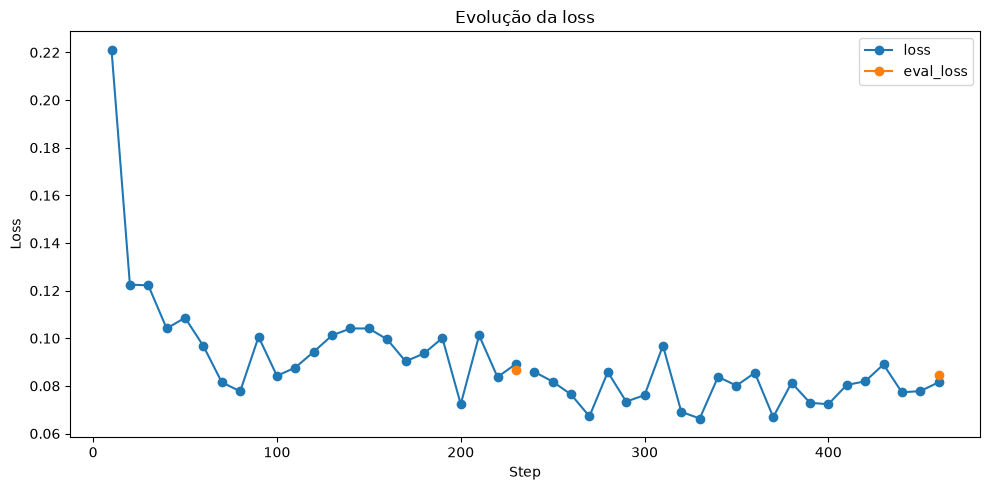

Checkpoints encontrados:
- c:\Users\mdbaa\development\alura\alura-llama-factory\EscutIA\fine_tuning_lora\outputs\resultados\lora_escutia_router\checkpoint-230
- c:\Users\mdbaa\development\alura\alura-llama-factory\EscutIA\fine_tuning_lora\outputs\resultados\lora_escutia_router\checkpoint-460


In [8]:
import pandas as pd

log_path = OUTPUT_DIR / 'trainer_log.jsonl'
if log_path.exists():
    registros_log = [json.loads(linha) for linha in log_path.read_text(encoding='utf-8').splitlines() if linha.strip()]
    df_log = pd.DataFrame(registros_log)
    if 'step' not in df_log.columns and 'current_steps' in df_log.columns:
        df_log['step'] = df_log['current_steps']
    display(df_log.tail())

    colunas_loss = [coluna for coluna in ['loss', 'eval_loss'] if coluna in df_log.columns]
    if colunas_loss and 'step' in df_log.columns:
        ax = df_log.plot(x='step', y=colunas_loss, figsize=(10, 5), marker='o')
        ax.set_title('Evolução da loss')
        ax.set_ylabel('Loss')
        ax.set_xlabel('Step')
        plt.tight_layout()
        plt.show()
    elif colunas_loss:
        print('Não foi possível gerar o gráfico: não há coluna de step no log.')
else:
    print(f'Log ainda não encontrado: {log_path}')

checkpoints = sorted(OUTPUT_DIR.glob('checkpoint-*')) if OUTPUT_DIR.exists() else []
print('Checkpoints encontrados:')
for checkpoint in checkpoints:
    print('-', checkpoint)


## 9. Como analisar o impacto dos hiperparâmetros

Para comparar configurações de forma confiável, altere uma variável por vez e mantenha o restante fixo. Registre a configuração, a loss, o tempo, o consumo de memória e o resultado na avaliação.

| Hiperparâmetro | Quando aumentar | Possível custo |
|---|---|---|
| rank | quando o adapter não tem capacidade suficiente | mais parâmetros e risco de sobreajuste |
| alpha | quando a atualização LoRA precisa de maior escala | mudanças mais fortes no comportamento |
| dropout | quando há sinais de sobreajuste | treinamento mais regularizado, mas possivelmente mais lento |
| learning rate | quando a adaptação está muito lenta | instabilidade ou perda de conhecimento |
| epochs | quando ainda há espaço para aprender | sobreajuste e maior tempo |
| batch efetivo | quando o gradiente está muito instável | maior memória ou mais acumulação |

Uma única execução não prova qual configuração é melhor. Ela fornece uma primeira evidência para o ciclo controlado de treinamento e avaliação. Para comparar as execuções registradas, use `scripts/mlflow_tools.py compare` e ordene as configurações por evaluation loss e pelas métricas da avaliação congelada.

## Resultado desta etapa

Ao concluir o treinamento, teremos um adapter LoRA em outputs/resultados/lora_escutia_router e os checkpoints correspondentes. O adapter depende do modelo base para ser carregado.

O próximo notebook, de inferência, poderá carregar modelo base + adapter e testar novos textos. Essa demonstração não substitui a avaliação formal com o conjunto de avaliação congelado.